In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../results/summary_all_seeds.csv")
df.head()

,seed,cluster,top_genes,best_cell_type,jaccard
0,0,0,"CCL5,NKG7,B2M,CTSW,CST7,GZMA,IL32,HLA-C,HLA-A,...",NK,0.0909
1,0,4,"CD74,CD79A,HLA-DRA,CD79B,HLA-DPB1,HLA-DQA1,MS4...",B cell,0.1000
2,0,3,"LTB,IL32,CD3D,LDHB,IL7R,TPT1,CD3E,RPS25,CD2,RPS12",Naive CD4+ T,0.0909
3,0,5,"LYZ,S100A9,S100A8,TYROBP,CST3,FTL,FCN1,LGALS2,...",CD14+ Monocyte,0.0909
4,0,2,"GNLY,NKG7,GZMB,PRF1,CTSW,CST7,GZMA,HLA-C,B2M,F...",NK,0.2000


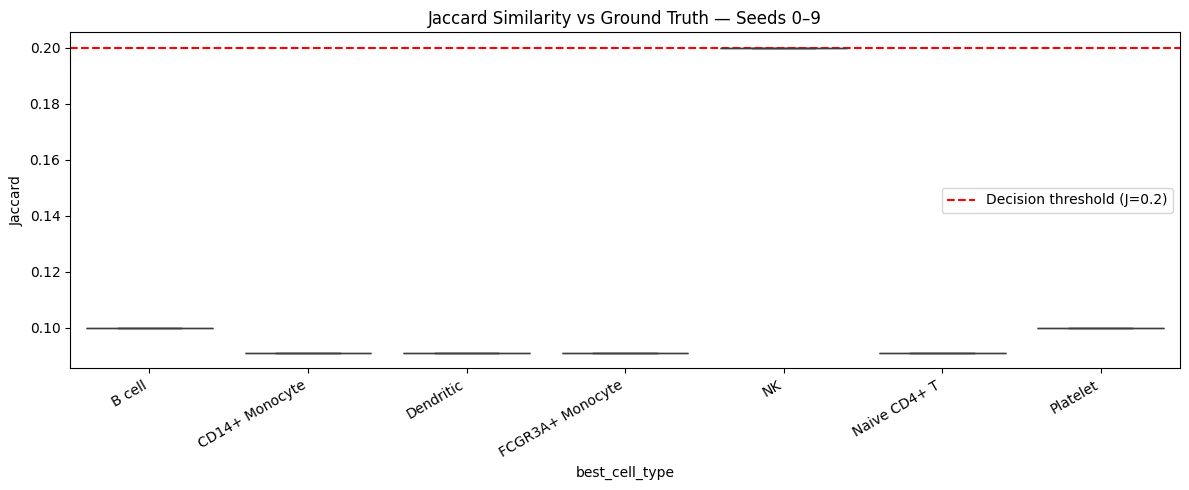

In [2]:
pivot = df.groupby(["seed", "best_cell_type"])["jaccard"].max().reset_index()

plt.figure(figsize=(12, 5))
sns.boxplot(data=pivot, x="best_cell_type", y="jaccard")
plt.axhline(0.2, color="red", linestyle="--", label="Decision threshold (J=0.2)")
plt.xticks(rotation=30, ha="right")
plt.title("Jaccard Similarity vs Ground Truth — Seeds 0–9")
plt.ylabel("Jaccard")
plt.legend()
plt.tight_layout()
plt.savefig("../../figures/jaccard_by_cell_type.png", dpi=150)
plt.show()

In [3]:
n_clusters = df.groupby("seed")["cluster"].nunique()
print(n_clusters.to_string())
print(f"\nMean: {n_clusters.mean():.1f}, Std: {n_clusters.std():.2f}")

seed
0    9
1    9
2    9
3    9
4    9
5    9
6    9
7    9
8    8
9    9

Mean: 8.9, Std: 0.32


In [5]:
PBMC3K_MARKERS = {
    "Naive CD4+ T":     ["IL7R", "CCR7"],
    "CD14+ Monocyte":   ["CD14", "LYZ"],
    "B cell":           ["MS4A1"],
    "CD8+ T":           ["CD8A"],
    "NK":               ["GNLY", "NKG7"],
    "FCGR3A+ Monocyte": ["FCGR3A", "MS4A7"],
    "Dendritic":        ["FCER1A", "CST3"],
    "Platelet":         ["PPBP"],
}

expected = set(PBMC3K_MARKERS.keys())
recovery = {}
for ct in expected:
    found_in = df[df["best_cell_type"] == ct]["seed"].nunique()
    recovery[ct] = found_in / 10

rec_df = pd.DataFrame.from_dict(recovery, orient="index", columns=["recovery_rate"])
print(rec_df.sort_values("recovery_rate"))

                  recovery_rate
CD8+ T                      0.0
FCGR3A+ Monocyte            0.9
B cell                      1.0
CD14+ Monocyte              1.0
Dendritic                   1.0
NK                          1.0
Naive CD4+ T                1.0
Platelet                    1.0


In [7]:
median_jaccard = df.groupby("best_cell_type")["jaccard"].median()
all_above_threshold = (median_jaccard >= 0.2).all()
full_recovery = all(v >= 0.8 for v in recovery.values())

if all_above_threshold and full_recovery:
    verdict = "FAIL TO REJECT H0 — Pipeline is consistent with ground truth across seeds 0–9."
else:
    verdict = "REJECT H0 — Pipeline results diverge from ground truth. Check normalization or resolution."

print("=" * 60)
print(verdict)
print("=" * 60)

REJECT H0 — Pipeline results diverge from ground truth. Check normalization or resolution.
